# P300 ERP Classifier Training

Trains a target-vs-nontarget flash classifier from calibration sessions recorded with the **P300 tab** (`Tabs…` → P300).

**Workflow:** record one session per word and save as `data/hello1.npz`, `data/hello2.npz`, … — this notebook loads them all, preprocesses, visualises the ERP, compares models, and saves the winner to `models/p300/`.

Expected file layout per session (written by the app): `X` (n,1,ch,t), `y` (n,) 1=target, `fs`, `pre_ms`, `post_ms`, `flash_meta`, `grid`.

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, resample_poly

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_curve, auc

%matplotlib inline

PATTERN = '../data/papi/julio*.npz'   # hello1.npz, hello2.npz, ...
LP_CUTOFF = 12.0              # P300 lives ~1-12 Hz; higher bands are EMG/noise here
HP_CUTOFF = 1.0
LINE_FREQ = 50.0
TARGET_FS = 50.0              # downsample after lowpass (lighter features, less overfit)
# Mean-amplitude windows (s, post-flash) used as features
WINDOWS = [(0.15, 0.25), (0.25, 0.35), (0.30, 0.45), (0.35, 0.55), (0.45, 0.65), (0.55, 0.80)]
SEED = 0
rng = np.random.default_rng(SEED)

## 1. Load sessions

1 sessions, 477 flashes: 79 target / 398 nontarget (16.6% oddball)
epochs: (477, 8, 250), fs=250 Hz, window=[-200,+800] ms


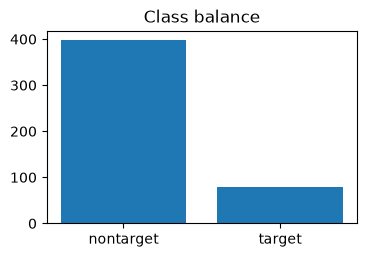

In [19]:
files = sorted(glob.glob(PATTERN))
assert files, (f"No files match '{PATTERN}'. Record a session with the P300 tab "
               "and save it as data/hello1.npz, data/hello2.npz, ...")

Xs, ys, metas = [], [], []
ref = None
for fn in files:
    z = np.load(fn, allow_pickle=True)
    key = (float(z['fs']), int(z['pre_ms']),
           int(z['post_ms']), z['X'].shape[2])
    if ref is None:
        ref = key
    elif key != ref:
        print(f"SKIP {fn}: fs/pre/post/ch mismatch {key} vs {ref}")
        continue
    Xs.append(z['X'][:, 0, :, :].astype(np.float64))  # (n, ch, t)
    ys.append(z['y'].astype(int))
    metas.append((fn, z['flash_meta']))

X = np.concatenate(Xs)          # (N, ch, t), raw µV
y = np.concatenate(ys)          # (N,) 1 = target row/col
fs, pre_ms, post_ms, n_ch = ref[0], ref[1], ref[2], ref[3]
t = np.linspace(-pre_ms / 1000, post_ms / 1000, X.shape[2])
print(f"{len(files)} sessions, {len(y)} flashes: "
      f"{int(y.sum())} target / {int((1 - y).sum())} nontarget "
      f"({y.mean() * 100:.1f}% oddball)")
print(f"epochs: {X.shape}, fs={fs:g} Hz, window=[{-pre_ms},+{post_ms}] ms")

fig, ax = plt.subplots(figsize=(4, 2.5))
ax.bar(['nontarget', 'target'], [(1 - y).sum(), y.sum()])
ax.set_title('Class balance')
plt.show()

## 2. Preprocessing: notch → bandpass → baseline → downsample

Filters are zero-phase (`filtfilt`/`sosfiltfilt`) so the P300 peak stays at 300 ms.

cleaned: (477, 8, 50) at 50 Hz


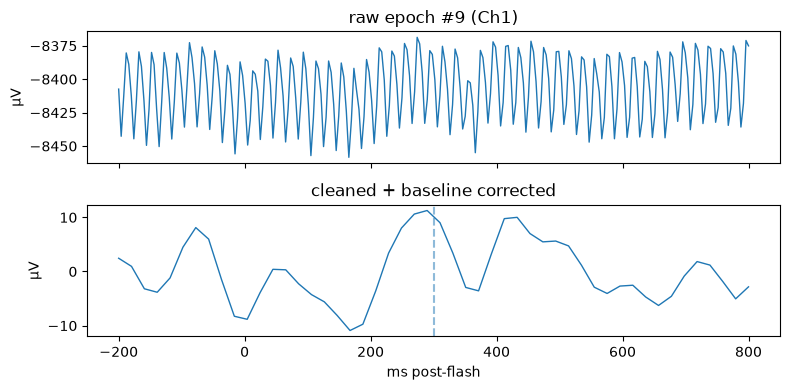

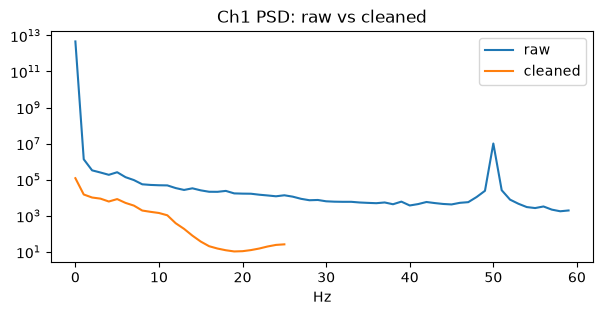

In [20]:
def preprocess(X, fs, hp=HP_CUTOFF, lp=LP_CUTOFF, line=LINE_FREQ,
               target_fs=TARGET_FS, pre_ms=pre_ms):
    """X: (N, ch, t) µV -> (N, ch, t_ds) cleaned, downsampled."""
    Y = X - X.mean(axis=2, keepdims=True)          # DC per epoch
    if 0 < line < fs / 2:
        b, a = iirnotch(line, 30.0, fs=fs)
        Y = filtfilt(b, a, Y, axis=2)
    sos = butter(4, [hp, lp], btype='bandpass', fs=fs, output='sos')
    Y = sosfiltfilt(sos, Y, axis=2)
    n_pre = int(round(pre_ms / 1000 * fs))         # baseline [-pre, 0]
    Y = Y - Y[:, :, :n_pre].mean(axis=2, keepdims=True)
    if target_fs and target_fs < fs:
        Y = resample_poly(Y, int(target_fs), int(fs), axis=2)
        fs = target_fs
    return Y, fs


Xp, fsd = preprocess(X, fs)
tp = np.linspace(-pre_ms / 1000, post_ms / 1000, Xp.shape[2])
print(f"cleaned: {Xp.shape} at {fsd:g} Hz")

# Before/after on one target epoch, one channel
ti = np.flatnonzero(y == 1)[0]
fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax[0].plot(t * 1000, X[ti, 0], lw=1)
ax[0].set_title(f'raw epoch #{ti} (Ch1)')
ax[0].set_ylabel('µV')
ax[1].plot(tp * 1000, Xp[ti, 0], lw=1)
ax[1].set_title('cleaned + baseline corrected')
ax[1].set_ylabel('µV')
ax[1].set_xlabel('ms post-flash')
ax[1].axvline(300, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# PSD before/after (average over 50 epochs)
sel = rng.choice(len(X), min(50, len(X)), replace=False)
fig, ax = plt.subplots(figsize=(7, 3))
for data, tt, _fs, name in [(X[sel, 0], t, fs, 'raw'), (Xp[sel, 0], tp, fsd, 'cleaned')]:
    f = np.fft.rfftfreq(data.shape[1], 1 / _fs)
    p = (np.abs(np.fft.rfft(data, axis=1)) ** 2).mean(axis=0)
    ax.semilogy(f[f < 60], p[f < 60], label=name)
ax.set_title('Ch1 PSD: raw vs cleaned')
ax.set_xlabel('Hz')
ax.legend()
plt.show()

## 3. ERP visualisation: is there a P300?

Grand-average target vs nontarget. A healthy oddball shows a positive target deflection ~250–500 ms, strongest over central/parietal channels.

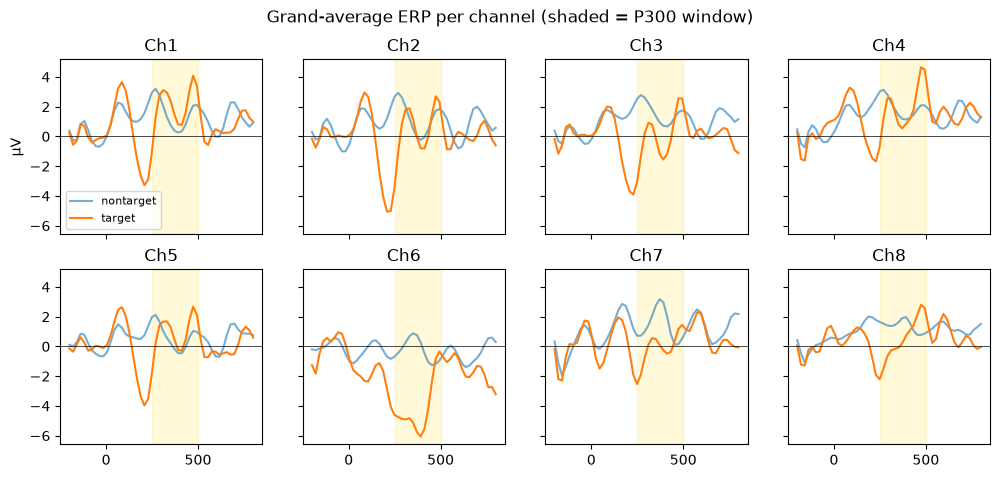

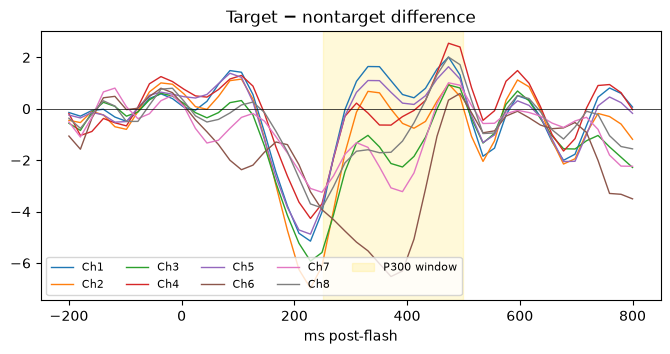

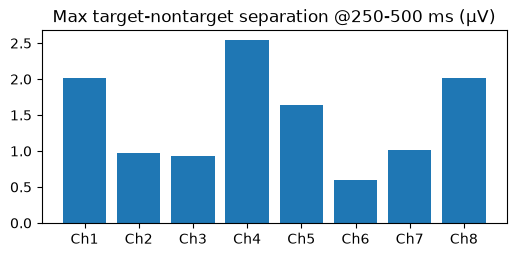

In [21]:
tgt, nont = Xp[y == 1].mean(axis=0), Xp[y == 0].mean(axis=0)  # (ch, t)
diff = tgt - nont

fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
for ch in range(n_ch):
    ax = axes.flat[ch]
    ax.plot(tp * 1000, nont[ch], alpha=0.6, label='nontarget')
    ax.plot(tp * 1000, tgt[ch], label='target')
    ax.axvspan(250, 500, color='gold', alpha=0.15)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(f'Ch{ch + 1}')
axes.flat[0].legend(fontsize=8)
axes.flat[0].set_ylabel('µV')
fig.suptitle('Grand-average ERP per channel (shaded = P300 window)')
plt.show()

# Difference wave (target − nontarget), all channels overlaid
fig, ax = plt.subplots(figsize=(8, 3.5))
for ch in range(n_ch):
    ax.plot(tp * 1000, diff[ch], lw=1, label=f'Ch{ch + 1}')
ax.axvspan(250, 500, color='gold', alpha=0.15, label='P300 window')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Target − nontarget difference')
ax.set_xlabel('ms post-flash')
ax.legend(ncol=5, fontsize=8)
plt.show()

# Peak target-nontarget separation per channel in the P300 window
m = (tp >= 0.25) & (tp <= 0.50)
peaks = diff[:, m].max(axis=1)
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.bar([f'Ch{i + 1}' for i in range(n_ch)], peaks)
ax.set_title('Max target-nontarget separation @250-500 ms (µV)')
plt.show()

## 4. Features: windowed mean amplitudes

Classic P300 recipe — mean voltage in fixed post-stimulus windows per channel. `n_ch × len(WINDOWS)` features, no peak-picking, robust to latency jitter.

features: (477, 48) = 8 ch x 6 windows


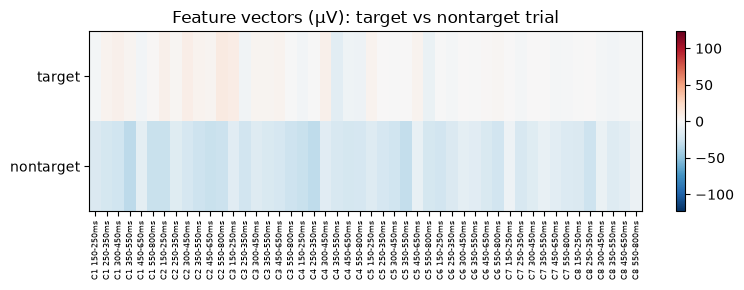

In [22]:
def window_features(Xp, tp, windows=WINDOWS):
    feats = []
    for lo, hi in windows:
        m = (tp >= lo) & (tp <= hi)
        feats.append(Xp[:, :, m].mean(axis=2))
    return np.concatenate(feats, axis=1)  # (N, ch*W)


F = window_features(Xp, tp)
print(f"features: {F.shape} = {n_ch} ch x {len(WINDOWS)} windows")

# Example: one target vs one nontarget trial in feature space
fig, ax = plt.subplots(figsize=(8, 3))
ni = np.flatnonzero(y == 0)[0]
im = ax.imshow(np.vstack([F[ti], F[ni]]), aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(F).max(), vmax=np.abs(F).max())
ax.set_yticks([0, 1], ['target', 'nontarget'])
ax.set_xticks(range(F.shape[1]),
              [f'C{c + 1} {lo * 1000:.0f}-{hi * 1000:.0f}ms'
               for c in range(n_ch) for lo, hi in WINDOWS],
              rotation=90, fontsize=6)
ax.set_title('Feature vectors (µV): target vs nontarget trial')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 5. Model comparison (stratified 5-fold CV)

Candidate linears suited to small ERP sets plus an RBF-SVM and a chance baseline. Metric that matters for typing: **ROC-AUC** (ranking target above nontarget), with balanced accuracy alongside.

chance     acc=0.744±0.021 bal=0.492±0.037 AUC=0.492±0.037
LDA        acc=0.849±0.035 bal=0.666±0.077 AUC=0.777±0.079
shrink-LDA acc=0.857±0.008 bal=0.635±0.046 AUC=0.794±0.071
logreg-C1  acc=0.853±0.016 bal=0.638±0.050 AUC=0.792±0.064
rbf-SVM    acc=0.834±0.004 bal=0.510±0.015 AUC=0.719±0.082


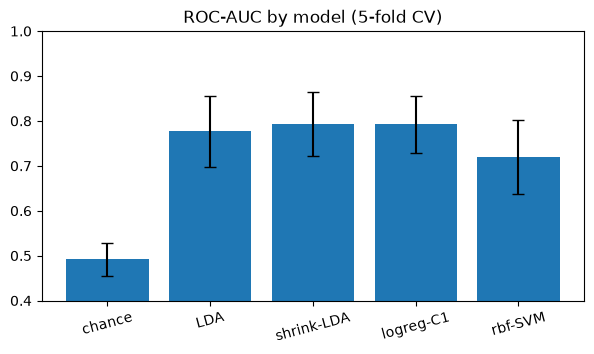

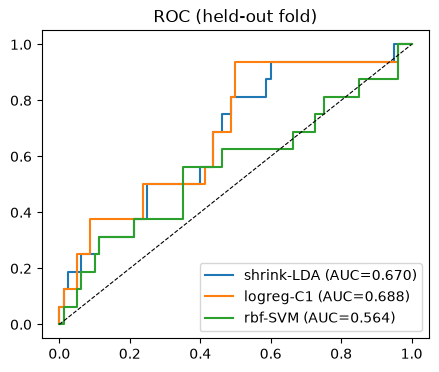

In [23]:
models = {
    'chance': make_pipeline(StandardScaler(),
                            DummyClassifier(strategy='stratified', random_state=SEED)),
    'LDA': make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    'shrink-LDA': make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
    'logreg-C1': make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000)),
    'rbf-SVM': make_pipeline(StandardScaler(), CalibratedClassifierCV(SVC(C=1.0), cv=3)),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
res = {}
for name, clf in models.items():
    s = cross_validate(clf, F, y, cv=cv,
                       scoring=['accuracy', 'balanced_accuracy', 'roc_auc'])
    res[name] = {k: (v.mean(), v.std())
                 for k, v in s.items() if k.startswith('test_')}
    m = res[name]
    print(f"{name:10s} acc={m['test_accuracy'][0]:.3f}±{m['test_accuracy'][1]:.3f} "
          f"bal={m['test_balanced_accuracy'][0]:.3f}±{m['test_balanced_accuracy'][1]:.3f} "
          f"AUC={m['test_roc_auc'][0]:.3f}±{m['test_roc_auc'][1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
names = list(models)
means = [res[n]['test_roc_auc'][0] for n in names]
stds = [res[n]['test_roc_auc'][1] for n in names]
ax.bar(names, means, yerr=stds, capsize=4)
ax.set_ylim(0.4, 1.0)
ax.set_title('ROC-AUC by model (5-fold CV)')
plt.xticks(rotation=15)
plt.show()

# ROC curves (first fold) for the real contenders
fig, ax = plt.subplots(figsize=(5, 4))
tr, te = next(cv.split(F, y))
for name in ['shrink-LDA', 'logreg-C1', 'rbf-SVM']:
    clf = models[name].fit(F[tr], y[tr])
    p = clf.predict_proba(F[te])[:, 1]
    fpr, tpr, _ = roc_curve(y[te], p)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_title('ROC (held-out fold)')
ax.legend()
plt.show()

## 6. Typing simulation: accuracy vs sequences averaged

Spellers average consecutive sequences before deciding. This replays each session: per character, groups of 12 flashes form one sequence — averaging the winner's *target-row + target-col* scores should beat every nontarget row/col.

winner: shrink-LDA


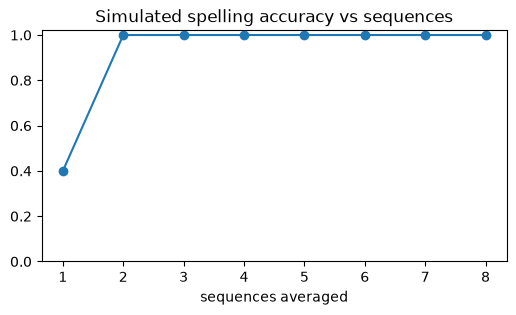

per-k accuracy: [0.4 1.  1.  1.  1.  1.  1.  1. ]


In [24]:
best_name = max([n for n in models if n != 'chance'],
                key=lambda n: res[n]['test_roc_auc'][0])
print('winner:', best_name)
clf = models[best_name].fit(F, y)
scores = clf.predict_proba(F)[:, 1]


def replay_accuracy(scores_list, y_list, meta_list, max_avg=8):
    """Per-char decoding: average k sequences, pick max row+col."""
    acc = []
    for scores, yy, (fn, meta) in zip(scores_list, y_list, meta_list):
        order = np.argsort([m['sample_idx'] for m in meta])
        chars = np.array([m['char'] for m in meta])[order]
        kinds = np.array([m['kind'] for m in meta])[order]
        idxs = np.array([m['idx'] for m in meta])[order]
        s = scores[order]
        for ch in sorted(set(chars)):
            m = chars == ch
            sc, kd, meta_idx = s[m], kinds[m], idxs[m]
            nseq = len(sc) // 12
            for k in range(1, min(max_avg, nseq) + 1):
                # average per (row/col, index) over the first k sequences
                # (kind order is reshuffled every sequence, so key by kind+idx)
                r = np.zeros(6)
                c = np.zeros(6)
                for j in range(k * 12):
                    if kd[j] == 'row':
                        r[int(meta_idx[j])] += sc[j] / k
                    else:
                        c[int(meta_idx[j])] += sc[j] / k
                pred = (int(np.argmax(r)), int(np.argmax(c)))
                grid = np.array(
                    list('ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789')).reshape(6, 6)
                while len(acc) < k:
                    acc.append([])
                acc[k - 1].append(grid[pred] == ch)
    return np.array([np.mean(a) if len(a) else np.nan for a in acc])


# per-session scores for replay
offsets = np.cumsum([0] + [len(a) for a in Xs])
sess_scores = [scores[offsets[i]:offsets[i + 1]] for i in range(len(Xs))]
sess_y = [ys[i] for i in range(len(ys))]
curve = replay_accuracy(sess_scores, sess_y, metas)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, len(curve) + 1), curve, marker='o')
ax.set_ylim(0, 1.02)
ax.set_xlabel('sequences averaged')
ax.set_title('Simulated spelling accuracy vs sequences')
plt.show()
print("per-k accuracy:", np.round(curve, 3))

## 7. Save the winner

In [25]:
import os
import joblib

os.makedirs('models/p300', exist_ok=True)
final = models[best_name].fit(F, y)
joblib.dump({'pipeline': final, 'windows': WINDOWS, 'fs': fsd,
             'pre_ms': pre_ms, 'post_ms': post_ms,
             'hp': HP_CUTOFF, 'lp': LP_CUTOFF, 'line': LINE_FREQ,
             'files': files, 'cv_auc': res[best_name]['test_roc_auc'][0]},
            'models/p300/classifier.joblib')
print(f"saved models/p300/classifier.joblib ({best_name}, "
      f"CV-AUC={res[best_name]['test_roc_auc'][0]:.3f}, N={len(y)})")

saved models/p300/classifier.joblib (shrink-LDA, CV-AUC=0.794, N=477)
